# Classification using k-Nearest Neighbors (k-NN)

## Aim
Classification using k-Nearest Neighbors (k-NN) and visualization of decision boundaries on the Wine dataset from `sklearn`.

In [6]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

In [7]:
# Load dataset
wine = load_wine()
X, y = wine.data, wine.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dataset shape: {X.shape}")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Target classes: {wine.target_names}")

Dataset shape: (178, 13)
Train shape: (142, 13), Test shape: (36, 13)
Target classes: ['class_0' 'class_1' 'class_2']


In [11]:
wine

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]], shape=(178, 13)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

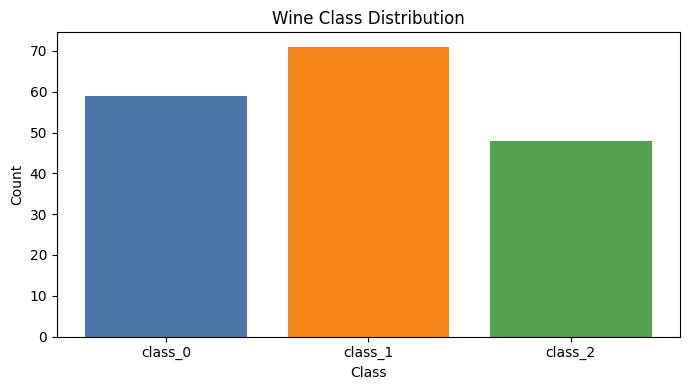

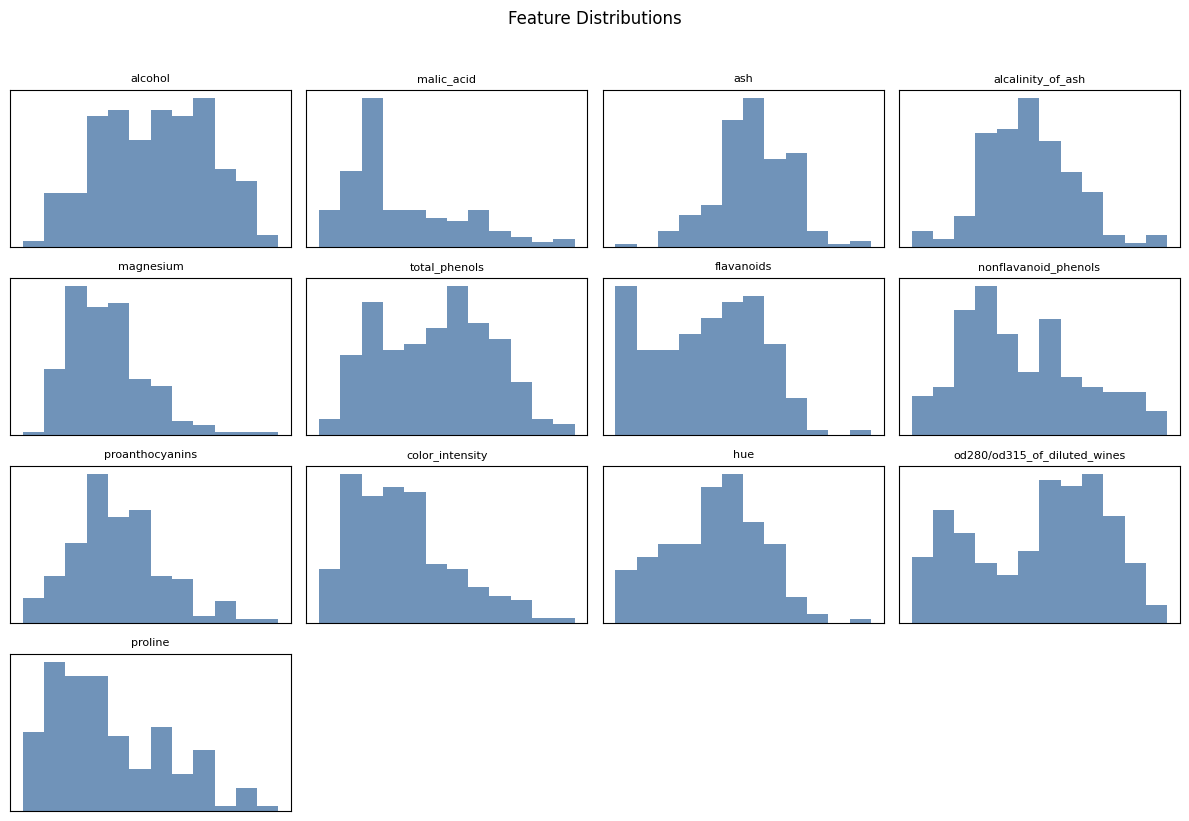

In [8]:
import matplotlib.pyplot as plt

# Class distribution
plt.figure(figsize=(7, 4))
plt.bar(wine.target_names, [sum(y == i) for i in range(len(wine.target_names))], color=["#4C78A8", "#F58518", "#54A24B"])
plt.title("Wine Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Histograms of all features (quick overview)
plt.figure(figsize=(12, 8))
for i in range(X.shape[1]):
    plt.subplot(4, 4, i + 1)
    plt.hist(X[:, i], bins=12, color="#4C78A8", alpha=0.8)
    plt.title(wine.feature_names[i], fontsize=8)
    plt.xticks([])
    plt.yticks([])
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

## Basic Visualizations

Simple plots to quickly understand class balance and feature spread.

In [9]:
# Create a simple KNN pipeline (scaling + classifier)
model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

# Train model
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

cm_df = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=[f"Actual_{name}" for name in wine.target_names],
    columns=[f"Pred_{name}" for name in wine.target_names]
)

print("Confusion Matrix:")
cm_df

Accuracy: 0.9722

Classification Report:

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      0.93      0.96        14
     class_2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36

Confusion Matrix:


,Pred_class_0,Pred_class_1,Pred_class_2
Actual_class_0,12,0,0
Actual_class_1,0,13,1
Actual_class_2,0,0,10


## Decision Boundary Visualization (2D PCA)

To visualize decision boundaries, we reduce the dataset to 2 dimensions using PCA and train a k-NN classifier on the reduced features.

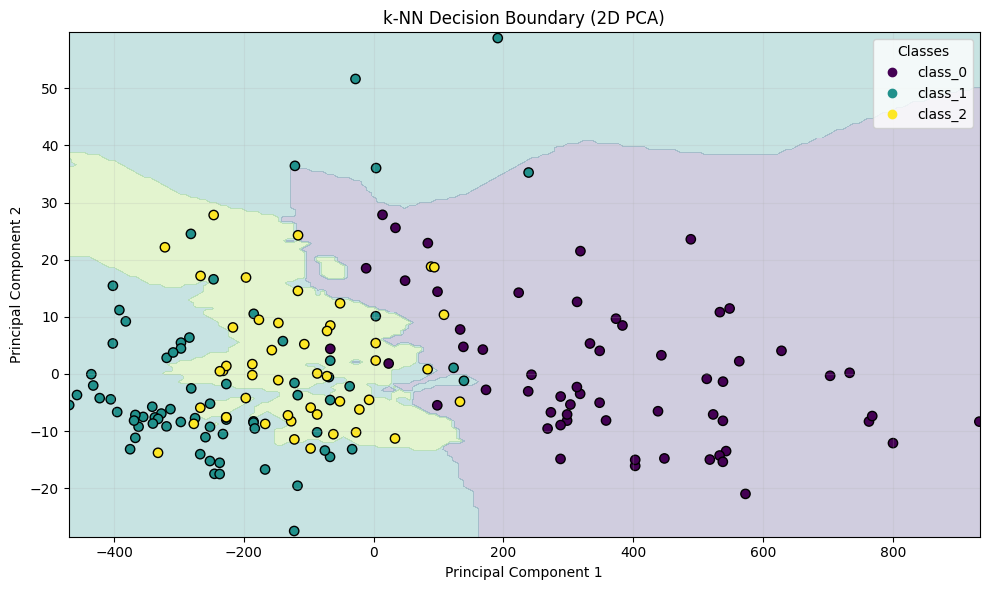

2D PCA model test accuracy: 0.7500


In [10]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Reduce data to 2D for visualization
X_pca = PCA(n_components=2, random_state=42).fit_transform(X)

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

# Keep model simple
knn_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
knn_2d.fit(X_train_2d, y_train_2d)

# Smaller mesh for faster plotting
x_min, x_max = X_pca[:, 0].min() - 1.0, X_pca[:, 0].max() + 1.0
y_min, y_max = X_pca[:, 1].min() - 1.0, X_pca[:, 1].max() + 1.0
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 180),
    np.linspace(y_min, y_max, 180)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = knn_2d.predict(grid).reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.25, levels=np.arange(len(wine.target_names) + 1) - 0.5, cmap="viridis")
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k",
    s=45
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("k-NN Decision Boundary (2D PCA)")
plt.grid(alpha=0.2)
handles, _ = scatter.legend_elements()
plt.legend(handles, wine.target_names, title="Classes")
plt.tight_layout()
plt.show()

print(f"2D PCA model test accuracy: {knn_2d.score(X_test_2d, y_test_2d):.4f}")